In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA




In [12]:
# LOAD DATA
v= pd.read_csv('/content/Superstore (2).csv',encoding='ISO-8859-1')
v

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,21-01-2014,23-01-2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,26-02-2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,26-02-2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,26-02-2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [48]:
v['Segment'].nunique()


3

# data preprocessing ..

In [14]:
# checking for null values
v.isnull().sum()  # there are no null values

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [15]:
# check the dtypes of all object...
v.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [16]:
# order date and ship date has to be in datetime format
v['Order Date']=pd.to_datetime(v['Order Date'],dayfirst=True)
v['Ship Date']= pd.to_datetime(v['Ship Date'],dayfirst=True)
v=v[v['Sales']>0]   # sales which are greater than 0 will appear..



In [18]:
v

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [19]:
sns.set(style='whitegrid')     # for plots ..

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [21]:
# coverting required categorical values to numeric for further process
# we are converting category,sub,regon,seg - label encoder...

In [23]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in ["Category","Sub-Category","Region","Segment"]:
  v[i]=le.fit_transform(v[i])


In [24]:
v

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,0,United States,Henderson,Kentucky,42420,2,FUR-BO-10001798,0,4,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,0,United States,Henderson,Kentucky,42420,2,FUR-CH-10000454,0,5,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,1,United States,Los Angeles,California,90036,3,OFF-LA-10000240,1,10,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,0,United States,Fort Lauderdale,Florida,33311,2,FUR-TA-10000577,0,16,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,0,United States,Fort Lauderdale,Florida,33311,2,OFF-ST-10000760,1,14,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,0,United States,Miami,Florida,33180,2,FUR-FU-10001889,0,9,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,0,United States,Costa Mesa,California,92627,3,FUR-FU-10000747,0,9,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,0,United States,Costa Mesa,California,92627,3,TEC-PH-10003645,2,13,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,0,United States,Costa Mesa,California,92627,3,OFF-PA-10004041,1,12,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [25]:
v.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

# 1) Can we predict the profit of a transaction?
Problem Type: Regression
Features to use: Sales, Quantity, Discount, Category, Sub-Category, Segment
Use case: Identify which factors impact profitability the most and forecast profit margins.

In [33]:
f =['Sales','Quantity','Discount','Category', 'Sub-Category','Segment']   # features
X = v[f]
y =v["Profit"]  # target variable


In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size= 0.2,random_state=42)
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X_train,y_train)
ypred=lr.predict(X_test)
mse =mean_squared_error(y_test,ypred)
print(f"\n1. Linear Regression MSE for profit prediction :{mse:.2f}")



1. Linear Regression MSE for profit prediction :82971.12


# 2) Which product categories are most likely to result in loss?
# classification problem
Problem Type: Classification (Profit > 0 = Profitable, else = Loss)
Features to use: Product, Sub-Category, Discount, Quantity, Region
Use case: Help the business minimize risk by flagging unprofitable products.

In [39]:
v["Loss_label"]=v["Profit"].apply(lambda x:1 if x < 0 else 0)
X_cls = v[f]
y_cls = v["Loss_label"]
X_train_c,X_test_c,y_train_c,y_test_c= train_test_split(X_cls,y_cls,test_size=0.2,random_state =42)
clf =RandomForestClassifier(random_state=42).fit(X_train_c,y_train_c)
ypredc=clf.predict(X_test_c)
acc=accuracy_score(y_test_c,ypredc)
print(f"\n2.Random Forest accuracy for loss classfication :{acc:.2%}")





2.Random Forest accuracy for loss classfication :95.10%


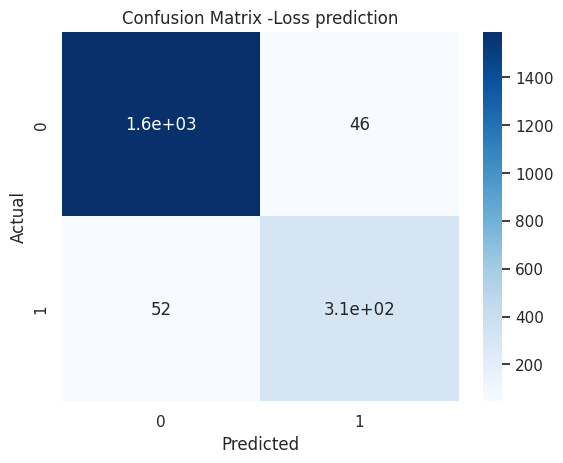

In [45]:
cm =confusion_matrix(y_test_c,ypredc)
sns.heatmap(cm, annot= True, cmap="Blues")
plt.title("Confusion Matrix -Loss prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


3)  # Can we cluster customers based on purchasing behavior?
Problem Type: Clustering (Unsupervised Learning)
Features to use: Total Spend, Average Discount, Quantity, Segment
Use case: Design personalized marketing campaigns for different customer segments.

In [49]:
cust_v= v.groupby('Customer ID').agg({
    'Sales': 'sum',
    'Discount': 'mean',
    'Quantity': 'mean',
    'Segment': 'first'
}).reset_index()


In [50]:
cust_v

,Customer ID,Sales,Discount,Quantity,Segment
0,AA-10315,5563.560,0.090909,2.727273,0
1,AA-10375,1056.390,0.080000,2.733333,0
2,AA-10480,1790.512,0.016667,3.000000,0
3,AA-10645,5086.935,0.063889,3.555556,0
4,AB-10015,886.156,0.066667,2.166667,0
...,...,...,...,...,...
788,XP-21865,2374.658,0.046429,3.571429,0
789,YC-21895,5454.350,0.075000,3.875000,1
790,YS-21880,6720.444,0.050000,4.833333,1
791,ZC-21910,8025.707,0.254839,3.387097,0


In [53]:
cust_v['Segment']=le.fit_transform(cust_v['Segment'])  # in above we had done fit here we are doing transform

,Segment
0,0
1,0
2,0
3,0
4,0
...,...
788,0
789,1
790,1
791,0


In [55]:
x_cust = cust_v[["Sales","Discount","Quantity","Segment"]]
scaler=StandardScaler()
x_scaled = scaler.fit_transform(x_cust)


In [56]:
x_scaled

array([[ 1.01511197, -0.74788484, -1.4848575 , -0.87040189],
       [-0.70059002, -0.87043891, -1.47637906, -0.87040189],
       [-0.4211387 , -1.58193339, -1.10332735, -0.87040189],
       ...,
       [ 1.45549211, -1.20746261,  1.46140309,  0.42702047],
       [ 1.9523543 ,  1.09372073, -0.56180069, -0.87040189],
       [-0.53403045, -0.52093285, -0.32613631, -0.87040189]])

In [57]:
kmeans = KMeans(n_clusters=3, random_state=42).fit(x_scaled)
cust_v['Cluster'] = kmeans.labels_

In [58]:
kmeans

KMeans(n_clusters=3, random_state=42)

In [59]:
cust_v

,Customer ID,Sales,Discount,Quantity,Segment,Cluster
0,AA-10315,5563.560,0.090909,2.727273,0,1
1,AA-10375,1056.390,0.080000,2.733333,0,1
2,AA-10480,1790.512,0.016667,3.000000,0,1
3,AA-10645,5086.935,0.063889,3.555556,0,1
4,AB-10015,886.156,0.066667,2.166667,0,1
...,...,...,...,...,...,...
788,XP-21865,2374.658,0.046429,3.571429,0,1
789,YC-21895,5454.350,0.075000,3.875000,1,0
790,YS-21880,6720.444,0.050000,4.833333,1,0
791,ZC-21910,8025.707,0.254839,3.387097,0,1


In [61]:
 # PCA for plotting clusters
pca = PCA(n_components=2)
cust_pca = pca.fit_transform(x_scaled)
cust_v['PC1'] = cust_pca[:, 0]
cust_v['PC2'] = cust_pca[:, 1]

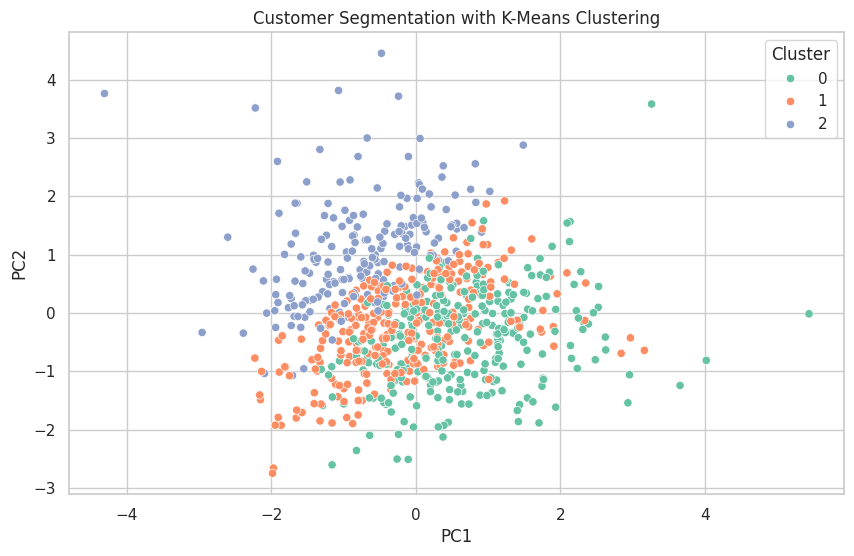

In [62]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cust_v, x='PC1', y='PC2', hue='Cluster', palette='Set2')
plt.title("Customer Segmentation with K-Means Clustering")
plt.show()

#  Can we predict the best shipping mode for a customer order?
Problem Type: Classification
Features to use: Order Date, Region, Product Category, Quantity, Segment
Use case: Optimize logistics by predicting preferred or most efficient shipping modes.

In [66]:
v['Ship Mode']=le.fit_transform(v['Ship Mode'])
X_ship=v[['Sales', 'Quantity', 'Discount', 'Category', 'Sub-Category', 'Segment']]
y_ship =v['Ship Mode']
X_trs,X_tests,y_trs,y_tests= train_test_split(X_ship,y_ship,test_size=0.2,random_state=42)
shipmodel = RandomForestClassifier(random_state=42).fit(X_trs,y_trs)
ypreds = shipmodel.predict(X_tests)
accur =accuracy_score(y_tests,ypreds)
print(f"\n.4 Random Forest Accuracy for shipping mode Prediction : {accur:.2%}")



.4 Random Forest Accuracy for shipping mode Prediction : 45.92%


#Can we forecast future sales based on historical order data?
Problem Type: Time Series Forecasting
Features to use: Date, Product Category, Region, Sales
Use case: Enable inventory planning, marketing budget allocation, and revenue forecasting.

In [106]:
v_sales_ts = v.groupby(v['Order Date'].dt.to_period('M')).agg({'Sales':'sum'}).reset_index()  # .dt.to_period m means we will get only year month data..
v_sales_ts['Order Date'] = v_sales_ts['Order Date'].dt.to_timestamp()

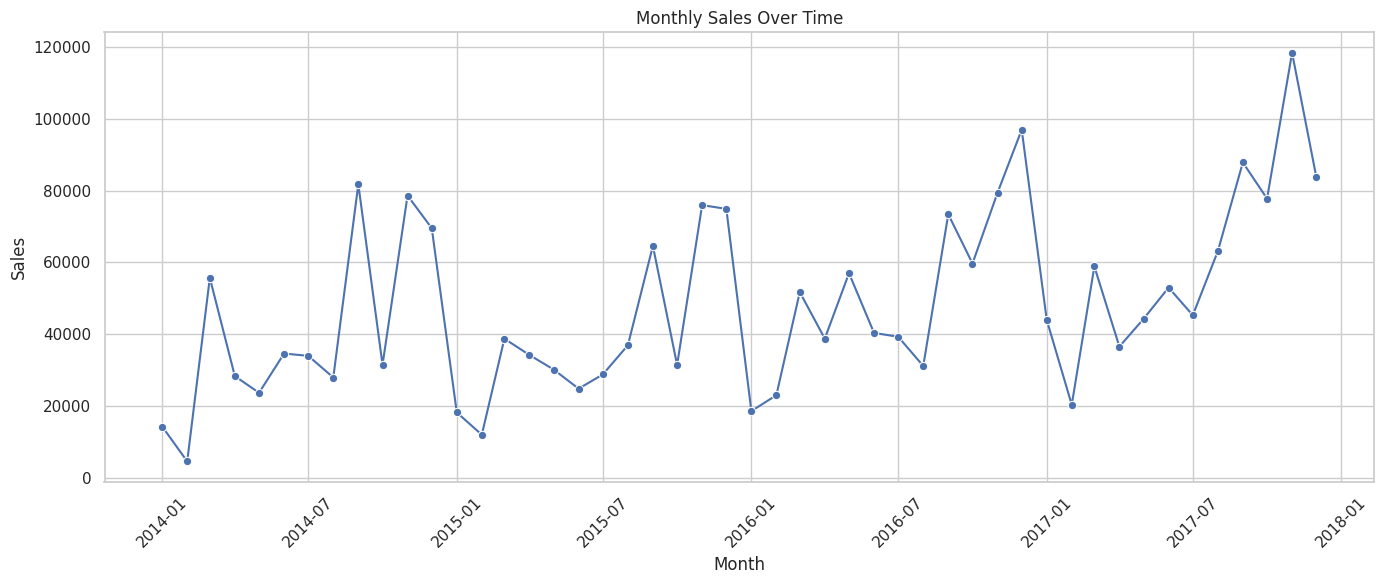

In [105]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=v_sales_ts, x='Order Date', y='Sales', marker='o')
plt.title("Monthly Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

AttributeError: 'DatetimeProperties' object has no attribute 'to_timestamp'